# Support Vector Regression (SVR)

## Importar bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importar el dataset

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [ ]:
print(X)

In [ ]:
print(y)

In [4]:
y = y.reshape(len(y),1) #Lo quito porque necesito que y sea 1D porque en el escalado StandardScaler espera 2D

In [ ]:
print(y)

## Escalado de variables

In [5]:
# En SVR es necesario escalar
# Ojo aquí, porque no hay muchos datos, no escalamos el entrenamiento (no hay separación previa) sino todo X y todo Y

from sklearn.preprocessing import StandardScaler
# hacemos dos escalados, en x y en y porque las transformaciones de escala serán diferentes para el vector X y para el vector y
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

In [ ]:
# Ahora y es 2D pero SVR necesitará .ravel() para volver a aplanarla a 1D

In [ ]:
print(X)

In [ ]:
print(y)

## Training the SVR model on the whole dataset

In [6]:
from sklearn.svm import SVR
regression = SVR(kernel = 'rbf') # rbf = Kernel Gaussiano, podríoa se 'linear', 'poly', sigmoid'
regression.fit(X, np.ravel(y))# np.ravel() aplana un array multidimensional en un vector 1D (una sola dimensión)

SVR()

## Predicting a new result

In [7]:
y_pred_scaled = regression.predict(sc_X.transform([[6.5]]))

In [8]:
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()[0]

In [9]:
y_pred= y_pred.ravel()[0]

In [10]:
y_pred

252789.13921623852

In [ ]:
print("mean_:", sc_y.mean_.ravel(), "scale_:", sc_y.scale_.ravel())
# Si ves ~[0.] y ~[1.], has ajustado el scaler sobre y YA estandarizado.


In [ ]:
sc_y.inverse_transform(regression.predict(sc_X.transform([[6.5]])).reshape(-1,1))

## Visualising the SVR results

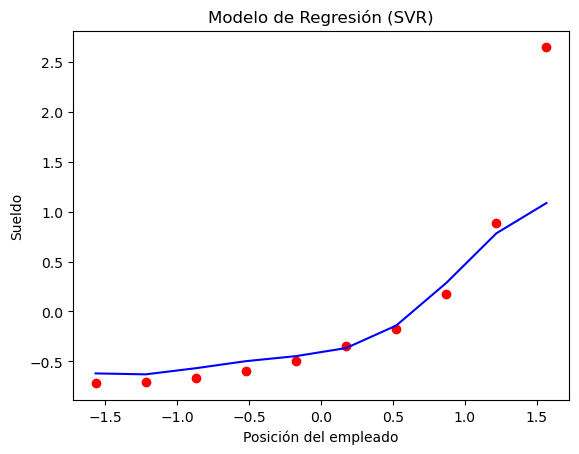

In [11]:
# Si hacemos Visualización sin escalado -> No sirve en SVR es necesario escalar -> La regresión sale horizontal. Nada que ver con los datos
# Si hacemos visualización con escalado no veremos los datos originales sino escalados, el dato del CEO se escapa a la regresión

plt.scatter(X, y, color= "red")
plt.plot(X, regression.predict(X), color ='blue')
plt.title('Modelo de Regresión (SVR)')
plt.xlabel('Posición del empleado')
plt.ylabel('Sueldo')
plt.show()

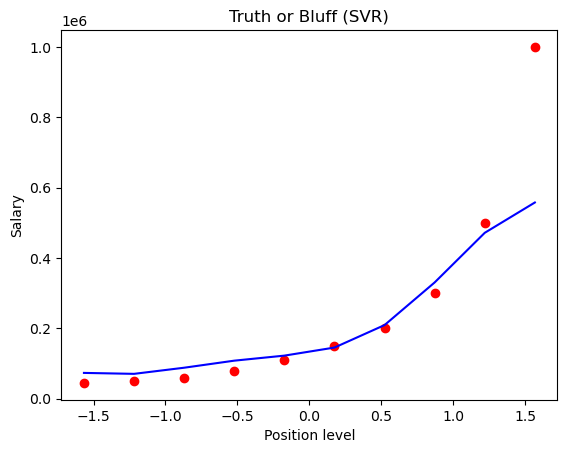

In [12]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regression.predict(X).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## Visualising the SVR results (for higher resolution and smoother curve)

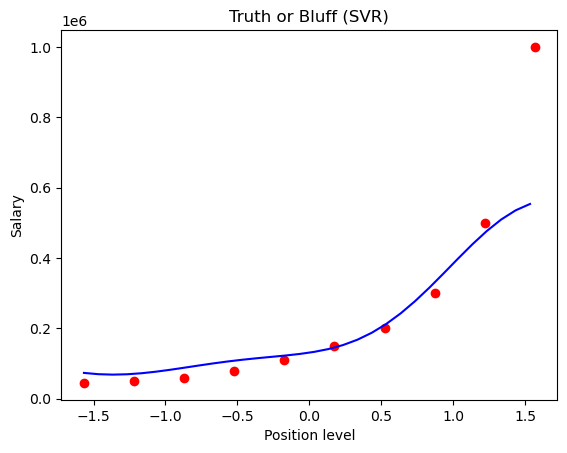

In [13]:
X_grid = np.arange(min(sc_X.inverse_transform(X)), max(sc_X.inverse_transform(X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regression.predict(sc_X.transform(X_grid)).reshape(-1,1)), color = 'blue')

plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()